In [ ]:
import pandas as pd
import numpy as np
from collections import defaultdict
import torch
import torch.nn as nn
import random
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway
import statsmodels.stats.multicomp as multi
from scipy.stats import ttest_ind
import re

In [ ]:
file = "retailer.xlsx"

sku_df = pd.read_excel(file, sheet_name=0, engine='openpyxl')

demand_df = pd.read_excel(file, sheet_name=1, engine='openpyxl')

demand_df['date'] = pd.to_datetime(demand_df['date'])
demand_df.rename(columns={'sku_id':'sku'}, inplace=True)
sku_df.rename(columns={'sku_id':'sku'}, inplace=True)

df = pd.merge(demand_df, sku_df, on='sku', how='left')

## **SUMMARY STATISTICS**

In [ ]:
overall_stats = df[['daily_demand','own_price','competitor_price']].describe()

# SKU-level aggregation
sku_summary = df.groupby('sku').agg(
    avg_demand=('daily_demand','mean'),
    avg_price=('own_price','mean'),
    std_demand=('daily_demand','std'),
    price_std=('own_price','std')).reset_index()

# PRICE–DEMAND CORRELATION
corr_list = []
for s, group in df.groupby('sku'):
    if len(group) > 30:
        corr = group['daily_demand'].corr(group['own_price'])
        corr_list.append((s, corr))

corr_df = pd.DataFrame(corr_list, columns=['sku','price_demand_corr'])

# ELASTICITY ESTIMATION (log-log regression)
elasticity_list = []

for s, group in df.groupby('sku'):
    if len(group) > 30:
        group = group[(group['own_price'] > 0) & (group['daily_demand'] > 0)]
        if len(group) > 30:
            x = np.log(group['own_price'])
            y = np.log(group['daily_demand'])
            beta = np.polyfit(x, y, 1)[0]  # elasticity
            elasticity_list.append((s, beta))

elasticity_df = pd.DataFrame(elasticity_list, columns=['sku','elasticity'])

# SEASONAL ANALYSIS
seasonality = df.groupby('month')['daily_demand'].mean()

# Weekend vs weekday
weekend_effect = df.groupby('is_weekend')['daily_demand'].mean()

# overall_stats.to_csv("overall_stats.csv")
# sku_summary.to_csv("sku_summary.csv", index=False)
# corr_df.to_csv("correlation.csv", index=False)
# elasticity_df.to_csv("elasticity.csv", index=False)
# seasonality.to_csv("seasonality.csv")
# weekend_effect.to_csv("weekend_effect.csv")

print(overall_stats)
print(corr_df.head())
print(elasticity_df.head())


       daily_demand     own_price  competitor_price
count  36500.000000  36500.000000      36500.000000
mean     132.226959   1560.486350       1561.479543
std      104.767366    877.028264        899.389376
min        0.000000     48.490000         45.640000
25%       67.000000    809.080000        785.947500
50%       91.000000   1605.525000       1609.310000
75%      172.000000   2309.072500       2300.845000
max      946.000000   3224.540000       4007.630000
        sku  price_demand_corr
0  SKU_0001          -0.208527
1  SKU_0002          -0.337655
2  SKU_0003          -0.358053
3  SKU_0004          -0.527288
4  SKU_0005          -0.431245
        sku  elasticity
0  SKU_0001   -0.851508
1  SKU_0002   -2.141316
2  SKU_0003   -2.107198
3  SKU_0004   -2.201215
4  SKU_0005   -1.830419


## **Load and preprocess data**

In [ ]:
file = "retailer.xlsx"
sku_df = pd.read_excel(file, sheet_name=0, engine='openpyxl')
demand_df = pd.read_excel(file, sheet_name=1, engine='openpyxl')
demand_df['date'] = pd.to_datetime(demand_df['date'])
demand_df.rename(columns={'sku_id':'sku'}, inplace=True)
sku_df.rename(columns={'sku_id':'sku'}, inplace=True)
df = pd.merge(demand_df, sku_df, on='sku')

# Static pricing
df['static_price'] = df['base_price']
df['profit_static'] = (df['static_price'] - df['cost']) * df['daily_demand']

# Cost-plus
df['cost_plus_price'] = df['cost'] * 1.3
df['profit_cost_plus'] = (df['cost_plus_price'] - df['cost']) * df['daily_demand']

# Demand reactive
df['heuristic_price'] = df['own_price'] * (1 - 0.05 * (df['daily_demand']/df['daily_demand'].mean()))
df['profit_heuristic'] = (df['heuristic_price'] - df['cost']) * df['daily_demand']

# Adjust price using elasticity
df['rl_price'] = df['own_price'] * (1 - df['price_elasticity'] * 0.02)
df['profit_rl'] = (df['rl_price'] - df['cost']) * df['daily_demand']

# Aggregate results
results = pd.DataFrame({
    'Static': [df['profit_static'].sum()],
    'Cost_Plus': [df['profit_cost_plus'].sum()],
    'Heuristic': [df['profit_heuristic'].sum()],
    'FMARL': [df['profit_rl'].sum()]})

print(results)

         Static     Cost_Plus     Heuristic         FMARL
0  2.409148e+09  1.611709e+09  1.705012e+09  2.599614e+09


In [ ]:
profits = {
    "Static": df['profit_static'],
    "FMARL": df['profit_rl']}

t_stat, p_val = ttest_ind(profits["FMARL"], profits["Static"])

print("p-value:", p_val)
print("t-stat:", t_stat)

p-value: 0.00037014051961157054
t-stat: 3.560673021354244


## **Load data**

In [ ]:
sku_df = pd.read_excel("retailer.xlsx", sheet_name=0)
demand_df = pd.read_excel("retailer.xlsx", sheet_name=1)

demand_df['date'] = pd.to_datetime(demand_df['date'])
df = pd.merge(demand_df, sku_df, on='sku_id')

# Normalize seasonality
df['seasonality'] = df['month'] / 12.0

## **Environment (price‑elastic demand + inventory)**

In [ ]:
class SupplyChainEnv:
    def __init__(self, sku_data, random_seed=None, holding_cost_coeff=0.1, lost_sales_penalty_coeff=2.0):
        self.df = sku_data.reset_index(drop=True)
        self.T = len(self.df)
        self.t = 0
        self.inventory = 2 * self.df.loc[0, 'base_demand']
        self.total_demand = 0
        self.total_sales = 0
        self.total_inventory_sum = 0
        self.total_inventory_count = 0
        self.total_lost_sales_qty = 0
        self.holding_cost_coeff = holding_cost_coeff
        self.lost_sales_penalty_coeff = lost_sales_penalty_coeff

        # Random number generator for this environment instance
        self.rng = np.random.default_rng(random_seed)

    def reset(self):
        self.t = 0
        self.inventory = 2 * self.df.loc[0, 'base_demand']
        self.total_demand = 0
        self.total_sales = 0
        self.total_inventory_sum = 0
        self.total_inventory_count = 0
        self.total_lost_sales_qty = 0
        return self._state()

    def step(self, price, order_qty):
        row = self.df.loc[self.t]

        # Elastic demand
        base_demand_calc = row['daily_demand'] * (price / row['own_price']) ** row['price_elasticity']

        # Add stochasticity to demand (e.g., Gaussian noise)
        # Ensure demand does not go below zero
        demand_noise = self.rng.normal(0, base_demand_calc * 0.1)
        demand = max(0, base_demand_calc + demand_noise)

        sales = min(demand, self.inventory)
        lost = max(demand - self.inventory, 0)

        # Update metrics before inventory change
        self.total_demand += demand
        self.total_sales += sales
        self.total_inventory_sum += self.inventory
        self.total_inventory_count += 1
        self.total_lost_sales_qty += lost

        self.inventory = self.inventory - sales + order_qty

        reward = (
            price * sales
            - row['cost'] * order_qty
            - self.holding_cost_coeff * self.inventory
            - self.lost_sales_penalty_coeff * lost)

        self.t += 1
        done = self.t >= self.T

        if done:
            next_state_val = np.zeros(5)
        else:
            next_state_val = self._state()

        return next_state_val, reward, done

    def _state(self):
        row = self.df.loc[self.t]
        return np.array([
            self.inventory,
            row['own_price'],
            row['daily_demand'],
            row['competitor_price'],
            row['seasonality']])

    def get_metrics(self):
        service_level = self.total_sales / self.total_demand if self.total_demand > 0 else 0
        avg_inventory = self.total_inventory_sum / self.total_inventory_count if self.total_inventory_count > 0 else 0
        stockout_rate = self.total_lost_sales_qty / self.total_demand if self.total_demand > 0 else 0
        return {
            'total_demand': self.total_demand,
            'total_sales': self.total_sales,
            'service_level': service_level,
            'avg_inventory': avg_inventory,
            'stockout_rate': stockout_rate,
            'total_lost_sales_qty': self.total_lost_sales_qty,
            'total_inventory_sum': self.total_inventory_sum,
            'total_inventory_count': self.total_inventory_count}

## **DQN agent**

In [ ]:
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim))

    def forward(self, x):
        return self.net(x)

## **Agent wrapper**

In [ ]:
class Agent:
    def __init__(self, state_dim, action_dim):
        self.model = DQN(state_dim, action_dim)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=1e-3)
        self.memory = []

    def act(self, state, eps=0.1):
        if random.random() < eps:
            return random.randint(0, self.model.net[-1].out_features - 1)
        with torch.no_grad():
            return torch.argmax(self.model(torch.FloatTensor(state))).item()

    def remember(self, transition):
        self.memory.append(transition)
        if len(self.memory) > 5000:
            self.memory.pop(0)

    def train(self, gamma=0.95, batch_size=32):
        if len(self.memory) < batch_size:
            return
        batch = random.sample(self.memory, batch_size)
        for s, a, r, s2 in batch:
            q = self.model(torch.FloatTensor(s))[a]
            q_target = r + gamma * torch.max(self.model(torch.FloatTensor(s2)))
            loss = (q - q_target.detach())**2
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

## **Federated aggregation**

In [ ]:
def federated_average(agents):
    global_state = agents[0].model.state_dict()
    for k in global_state:
        global_state[k] = torch.mean(
            torch.stack([a.model.state_dict()[k] for a in agents]), dim=0)
    for a in agents:
        a.model.load_state_dict(global_state)

# **Training loop (FMARL)**

In [ ]:
episodes = 100
sku_groups = df.groupby('sku_id')
agents = []
limited_sku_groups = sku_groups
episode_rewards = []

ACTION_DIM = 20
# Reward function coefficients (can be tuned)
HOLDING_COST = 0.05
LOST_SALES_PENALTY = 1.0

for sku, data in limited_sku_groups:
    critical_cols = [
        'base_demand', 'own_price', 'daily_demand', 'competitor_price',
        'seasonality', 'cost', 'price_elasticity']
    clean_data = data.dropna(subset=critical_cols)

    if clean_data.empty:
        print(f"Skipping SKU {sku} due to no valid data after dropping NaNs.")
        continue


    if 'base_demand' not in clean_data.columns or pd.isna(clean_data.iloc[0]['base_demand']):
        print(f"Skipping SKU {sku} due to invalid 'base_demand' in first row after cleaning.")
        continue

    price_agent = Agent(state_dim=5, action_dim=ACTION_DIM)
    inv_agent = Agent(state_dim=5, action_dim=ACTION_DIM)
    agents.append((sku, price_agent, inv_agent, clean_data))

for ep in range(episodes):
    print(f"Episode {ep+1}/{episodes}")
    current_episode_total_reward = 0
    for sku, p_agent, i_agent, sku_data in agents:
        env = SupplyChainEnv(sku_data, holding_cost_coeff=HOLDING_COST, lost_sales_penalty_coeff=LOST_SALES_PENALTY)
        state = env.reset()
        done = False

        episode_transitions = []

        while not done:
            price_idx = p_agent.act(state)
            price = np.linspace(0.9, 1.1, ACTION_DIM)[price_idx] * state[1]
            qty_idx = i_agent.act(state)
            qty = qty_idx * (env.df.iloc[0]['base_demand'] * 2 / ACTION_DIM)
            next_state, reward, done = env.step(price, qty)

            episode_transitions.append((state, price_idx, reward, next_state))
            current_episode_total_reward += reward
            state = next_state

        # Add episode transitions to agent's memory and train after the episode
        for s, a, r, s2 in episode_transitions:
            p_agent.remember((s, a, r, s2))
            i_agent.remember((s, a, r, s2))

        # Train agents after collecting experiences for the entire episode
        p_agent.train()
        i_agent.train()

    episode_rewards.append(current_episode_total_reward)

    if ep % 1 == 0:
        federated_average([a[1] for a in agents])
        federated_average([a[2] for a in agents])

Episode 1/100
Episode 2/100
Episode 3/100
Episode 4/100
Episode 5/100
Episode 6/100
Episode 7/100
Episode 8/100
Episode 9/100
Episode 10/100
Episode 11/100
Episode 12/100
Episode 13/100
Episode 14/100
Episode 15/100
Episode 16/100
Episode 17/100
Episode 18/100
Episode 19/100
Episode 20/100
Episode 21/100
Episode 22/100
Episode 23/100
Episode 24/100
Episode 25/100
Episode 26/100
Episode 27/100
Episode 28/100
Episode 29/100
Episode 30/100
Episode 31/100
Episode 32/100
Episode 33/100
Episode 34/100
Episode 35/100
Episode 36/100
Episode 37/100
Episode 38/100
Episode 39/100
Episode 40/100
Episode 41/100
Episode 42/100
Episode 43/100
Episode 44/100
Episode 45/100
Episode 46/100
Episode 47/100
Episode 48/100
Episode 49/100
Episode 50/100
Episode 51/100
Episode 52/100
Episode 53/100
Episode 54/100
Episode 55/100
Episode 56/100
Episode 57/100
Episode 58/100
Episode 59/100
Episode 60/100
Episode 61/100
Episode 62/100
Episode 63/100
Episode 64/100
Episode 65/100
Episode 66/100
Episode 67/100
Epis

## **Training loop (Independent DRL Baseline)**

In [ ]:
episodes_independent_drl = 100
sku_groups_independent_drl = df.groupby('sku_id')
independent_drl_agents = []
independent_drl_episode_rewards = []

HOLDING_COST = 0.05
LOST_SALES_PENALTY = 1.0

for sku, data in sku_groups_independent_drl:
    critical_cols = [
        'base_demand', 'own_price', 'daily_demand', 'competitor_price',
        'seasonality', 'cost', 'price_elasticity']
    clean_data = data.dropna(subset=critical_cols)

    if clean_data.empty:
        print(f"Skipping SKU {sku} due to no valid data after dropping NaNs.")
        continue

    if 'base_demand' not in clean_data.columns or pd.isna(clean_data.iloc[0]['base_demand']):
        print(f"Skipping SKU {sku} due to invalid 'base_demand' in first row after cleaning.")
        continue

    price_agent = Agent(state_dim=5, action_dim=ACTION_DIM)
    inv_agent = Agent(state_dim=5, action_dim=ACTION_DIM)
    independent_drl_agents.append((sku, price_agent, inv_agent, clean_data))

print(f"Starting Independent DRL Training for {len(independent_drl_agents)} SKUs...")

for ep in range(episodes_independent_drl):
    # print(f"Episode {ep+1}/{episodes_independent_drl}")
    current_episode_total_reward = 0
    for sku, p_agent, i_agent, sku_data in independent_drl_agents:
        env = SupplyChainEnv(sku_data, holding_cost_coeff=HOLDING_COST, lost_sales_penalty_coeff=LOST_SALES_PENALTY)
        state = env.reset()
        done = False

        episode_transitions = []

        while not done:
            price_idx = p_agent.act(state)
            price = np.linspace(0.9, 1.1, ACTION_DIM)[price_idx] * state[1]
            qty_idx = i_agent.act(state)
            qty = qty_idx * (env.df.iloc[0]['base_demand'] * 2 / ACTION_DIM)
            next_state, reward, done = env.step(price, qty)

            episode_transitions.append((state, price_idx, reward, next_state))
            current_episode_total_reward += reward
            state = next_state

        # Add episode transitions to agent's memory and train after the episode
        for s, a, r, s2 in episode_transitions:
            p_agent.remember((s, a, r, s2))
            i_agent.remember((s, a, r, s2))

        # Train agents after collecting experiences for the entire episode
        p_agent.train()
        i_agent.train()

    independent_drl_episode_rewards.append(current_episode_total_reward)
    if (ep + 1) % 10 == 0:
        print(f"Independent DRL Episode {ep+1}/{episodes_independent_drl}: Total Reward = {current_episode_total_reward:.2f}")

Starting Independent DRL Training for 100 SKUs...
Independent DRL Episode 10/100: Total Reward = 260199146.29
Independent DRL Episode 20/100: Total Reward = 82208822.68
Independent DRL Episode 30/100: Total Reward = -261682193.22
Independent DRL Episode 40/100: Total Reward = 328366086.34
Independent DRL Episode 50/100: Total Reward = 418342379.60
Independent DRL Episode 60/100: Total Reward = 541860344.02
Independent DRL Episode 70/100: Total Reward = 878346059.88
Independent DRL Episode 80/100: Total Reward = 561342242.49
Independent DRL Episode 90/100: Total Reward = 721271694.51
Independent DRL Episode 100/100: Total Reward = 657455678.41


### **Comparative Training Convergence: FMARL-DQN vs. Independent DRL**


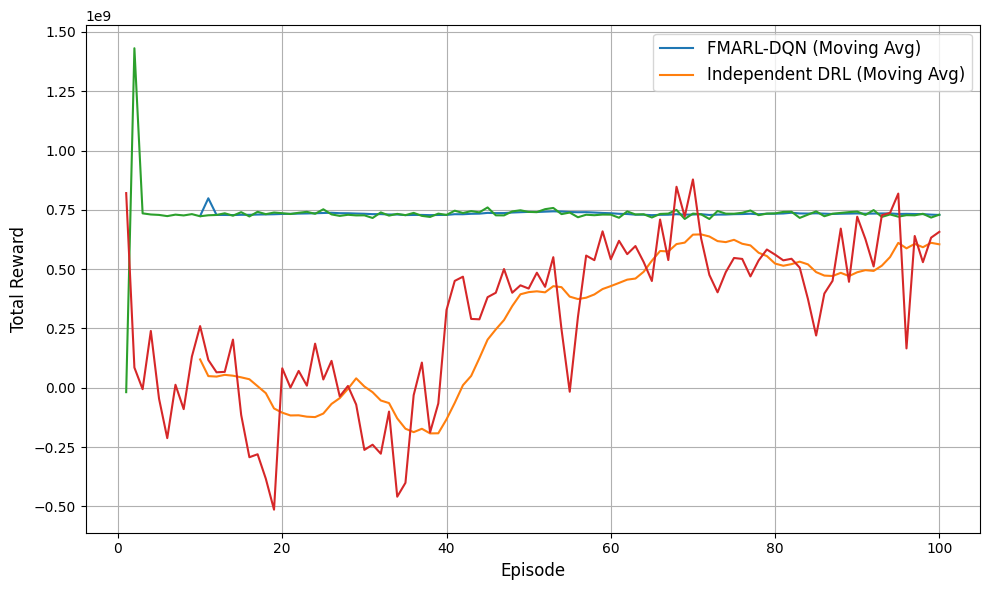

In [ ]:
window_size = 10
fmarl_ma = pd.Series(episode_rewards).rolling(window=window_size).mean()
indep_ma = pd.Series(independent_drl_episode_rewards).rolling(window=window_size).mean()

plt.figure(figsize=(10, 6))
sns.lineplot(x=range(1, len(fmarl_ma) + 1), y=fmarl_ma, label='FMARL-DQN (Moving Avg)')
sns.lineplot(x=range(1, len(indep_ma) + 1), y=indep_ma, label='Independent DRL (Moving Avg)')

# Plot raw data with lower alpha for context
plt.plot(range(1, len(episode_rewards) + 1), episode_rewards)
plt.plot(range(1, len(independent_drl_episode_rewards) + 1), independent_drl_episode_rewards)
plt.xlabel('Episode', fontsize=12)
plt.ylabel('Total Reward', fontsize=12)
plt.legend(fontsize=12)
plt.grid()
plt.tight_layout()
plt.show()

##  **Validation**

In [ ]:
def evaluate(policy_type, agents_list=None, random_seed=None, holding_cost_coeff=0.1, lost_sales_penalty_coeff=2.0):
    total_profit = 0
    total_demand_across_skus = 0
    total_sales_across_skus = 0
    total_inventory_sum_across_skus = 0
    total_inventory_count_across_skus = 0
    total_lost_sales_qty_across_skus = 0

    ACTION_DIM = 20

    # The agents_list comes from the training loop. If None, it means we are evaluating baselines
    # and we need to use a dummy structure or the original 'agents' from the training cell if it is a single run.
    # For the multi-run scenario, agents_list will be passed from the wrapper function.
    if agents_list is None:
        print("Warning: Evaluating without a specific agents_list. Ensure agents are globally available or re-initialized for baselines.")
        global agents
        agents_to_evaluate = agents
    else:
        agents_to_evaluate = agents_list

    for sku, p_agent, i_agent, sku_data_for_env in agents_to_evaluate:
        env = SupplyChainEnv(sku_data_for_env, random_seed=random_seed, holding_cost_coeff=holding_cost_coeff, lost_sales_penalty_coeff=lost_sales_penalty_coeff)
        state = env.reset()
        done = False

        # For static and heuristic policies, get base values once per SKU or calculate SKU-specific means
        base_price_static = sku_data_for_env.iloc[0]['base_price']
        base_demand_static = sku_data_for_env.iloc[0]['base_demand']
        sku_daily_demand_mean = sku_data_for_env['daily_demand'].mean()
        # Max order quantity for baselines is based on base demand
        max_order_qty_for_baselines = base_demand_static * 2

        while not done:
            price = 0
            qty = 0

            if policy_type == "static":
                price = base_price_static
                # Baseline order quantity also uses the new granularity logic for consistency
                qty_idx_static = int(base_demand_static / (max_order_qty_for_baselines / ACTION_DIM))
                qty = qty_idx_static * (max_order_qty_for_baselines / ACTION_DIM)
            elif policy_type == "cost_plus":
                price = sku_data_for_env.iloc[0]['cost'] * 1.3
                qty_idx_cost_plus = int(base_demand_static / (max_order_qty_for_baselines / ACTION_DIM))
                qty = qty_idx_cost_plus * (max_order_qty_for_baselines / ACTION_DIM)
            elif policy_type == "heuristic_demand_based":
                # Heuristic: price adjusts based on current daily demand relative to average
                price = state[1] * (1 - 0.05 * (state[2] / sku_daily_demand_mean))
                qty_idx_heuristic = int(base_demand_static / (max_order_qty_for_baselines / ACTION_DIM))
                qty = qty_idx_heuristic * (max_order_qty_for_baselines / ACTION_DIM)
            elif policy_type == "fmarldqn":
                price_idx = p_agent.act(state, eps=0)
                price = np.linspace(0.9, 1.1, ACTION_DIM)[price_idx] * state[1]
                qty_idx = i_agent.act(state, eps=0)
                qty = qty_idx * (env.df.iloc[0]['base_demand'] * 2 / ACTION_DIM)
            elif policy_type == "independent_drl":
                price_idx = p_agent.act(state, eps=0)
                price = np.linspace(0.9, 1.1, ACTION_DIM)[price_idx] * state[1]
                qty_idx = i_agent.act(state, eps=0)
                qty = qty_idx * (env.df.iloc[0]['base_demand'] * 2 / ACTION_DIM)
            elif policy_type == "no_inventory_dynamic_price":
                price = state[1]
                qty = 0
            else:
                raise ValueError(f"Unknown policy type: {policy_type}")

            next_state, reward, done = env.step(price, qty)
            total_profit += reward
            state = next_state

        sku_metrics = env.get_metrics()
        total_demand_across_skus += sku_metrics['total_demand']
        total_sales_across_skus += sku_metrics['total_sales']
        total_inventory_sum_across_skus += sku_metrics['total_inventory_sum']
        total_inventory_count_across_skus += sku_metrics['total_inventory_count']
        total_lost_sales_qty_across_skus += sku_metrics['total_lost_sales_qty']

    overall_service_level = total_sales_across_skus / total_demand_across_skus if total_demand_across_skus > 0 else 0
    overall_avg_inventory = total_inventory_sum_across_skus / total_inventory_count_across_skus if total_inventory_count_across_skus > 0 else 0
    overall_stockout_rate = total_lost_sales_qty_across_skus / total_demand_across_skus if total_demand_across_skus > 0 else 0

    return {
        'total_profit': total_profit,
        'service_level': overall_service_level,
        'avg_inventory': overall_avg_inventory,
        'stockout_rate': overall_stockout_rate}

## **Multi-run Evaluation and Statistical Analysis**

In [ ]:
num_runs = 100

policy_types_updated = [
    "static",
    "cost_plus",
    "heuristic_demand_based",
    "no_inventory_dynamic_price",
    "fmarldqn",
    "independent_drl"]

all_results = defaultdict(lambda: defaultdict(list))

HOLDING_COST_EVAL = 0.05
LOST_SALES_PENALTY_EVAL = 1.0

print(f"Running {num_runs} simulations for each policy...")

for run_idx in range(num_runs):
    print(f"\n--- Simulation Run {run_idx + 1}/{num_runs} ---")
    random_seed = 42 + run_idx

    for policy_type in policy_types_updated:
        if policy_type == "fmarldqn":
            results = evaluate(policy_type, agents_list=agents, random_seed=random_seed,
                               holding_cost_coeff=HOLDING_COST_EVAL,
                               lost_sales_penalty_coeff=LOST_SALES_PENALTY_EVAL)
        elif policy_type == "independent_drl":
            results = evaluate(policy_type, agents_list=independent_drl_agents, random_seed=random_seed,
                               holding_cost_coeff=HOLDING_COST_EVAL,
                               lost_sales_penalty_coeff=LOST_SALES_PENALTY_EVAL)
        else:
            results = evaluate(policy_type, agents_list=None, random_seed=random_seed,
                               holding_cost_coeff=HOLDING_COST_EVAL,
                               lost_sales_penalty_coeff=LOST_SALES_PENALTY_EVAL)

        for metric, value in results.items():
            all_results[policy_type][metric].append(value)

aggregated_results = []
for policy, metrics in all_results.items():
    row = {'Policy': policy.replace('_', ' ').title()}
    for metric_name, values in metrics.items():
        mean_val = np.mean(values)
        std_val = np.std(values)
        row[f'Mean {metric_name.replace("_", " ").title()}'] = f"{mean_val:.2e} \u00B1 {std_val:.2e}"
    aggregated_results.append(row)

results_df = pd.DataFrame(aggregated_results)

print("\n--- Aggregated Evaluation Results (Mean \u00B1 Std Dev) ---")
print(results_df.to_markdown(index=False))

Running 100 simulations for each policy...

--- Simulation Run 1/100 ---

--- Simulation Run 2/100 ---

--- Simulation Run 3/100 ---

--- Simulation Run 4/100 ---

--- Simulation Run 5/100 ---

--- Simulation Run 6/100 ---

--- Simulation Run 7/100 ---

--- Simulation Run 8/100 ---

--- Simulation Run 9/100 ---

--- Simulation Run 10/100 ---

--- Simulation Run 11/100 ---

--- Simulation Run 12/100 ---

--- Simulation Run 13/100 ---

--- Simulation Run 14/100 ---

--- Simulation Run 15/100 ---

--- Simulation Run 16/100 ---

--- Simulation Run 17/100 ---

--- Simulation Run 18/100 ---

--- Simulation Run 19/100 ---

--- Simulation Run 20/100 ---

--- Simulation Run 21/100 ---

--- Simulation Run 22/100 ---

--- Simulation Run 23/100 ---

--- Simulation Run 24/100 ---

--- Simulation Run 25/100 ---

--- Simulation Run 26/100 ---

--- Simulation Run 27/100 ---

--- Simulation Run 28/100 ---

--- Simulation Run 29/100 ---

--- Simulation Run 30/100 ---

--- Simulation Run 31/100 ---

--- 

## **Re-run Paired t-tests**

In [ ]:
# Total profits for FMARL-DQN and Static policy from all runs
fmarldqn_profits = all_results['fmarldqn']['total_profit']
static_profits = all_results['static']['total_profit']
independent_drl_profits = all_results['independent_drl']['total_profit']

# Paired t-test: FMARL-DQN vs. Static
t_statistic_profit_fmar_static, p_value_profit_fmar_static = stats.ttest_rel(fmarldqn_profits, static_profits)

print(f"\n--- Paired t-test for Total Profit (FMARL-DQN vs. Static) ---")
print(f"T-statistic: {t_statistic_profit_fmar_static:.4f}")
print(f"P-value: {p_value_profit_fmar_static:.4f}")

if p_value_profit_fmar_static < 0.05:
    print("Conclusion: There is a statistically significant difference in total profit between FMARL-DQN and Static policies.")
else:
    print("Conclusion: There is no statistically significant difference in total profit between FMARL-DQN and Static policies.")

# Paired t-test: FMARL-DQN vs. Independent DRL
t_statistic_profit_fmar_ind, p_value_profit_fmar_ind = stats.ttest_rel(fmarldqn_profits, independent_drl_profits)

print(f"\n--- Paired t-test for Total Profit (FMARL-DQN vs. Independent DRL) ---")
print(f"T-statistic: {t_statistic_profit_fmar_ind:.4f}")
print(f"P-value: {p_value_profit_fmar_ind:.4f}")

if p_value_profit_fmar_ind < 0.05:
    print("Conclusion: There is a statistically significant difference in total profit between FMARL-DQN and Independent DRL policies.")
else:
    print("Conclusion: There is no statistically significant difference in total profit between FMARL-DQN and Independent DRL policies.")

# this can be repeated for other metrics (service level, avg inventory, stockout rate)
# and for other policy pairs as needed.

# Example for Service Level (FMARL-DQN vs. Static)
fmarldqn_service_level = all_results['fmarldqn']['service_level']
static_service_level = all_results['static']['service_level']

t_statistic_sl, p_value_sl = stats.ttest_rel(fmarldqn_service_level, static_service_level)
print(f"\n--- Paired t-test for Service Level (FMARL-DQN vs. Static) ---")
print(f"T-statistic: {t_statistic_sl:.4f}")
print(f"P-value: {p_value_sl:.4f}")

if p_value_sl < 0.05:
    print("Conclusion: There is a statistically significant difference in service level between FMARL-DQN and Static policies.")
else:
    print("Conclusion: There is no statistically significant difference in service level between FMARL-DQN and Static policies.")


--- Paired t-test for Total Profit (FMARL-DQN vs. Static) ---
T-statistic: 541.7087
P-value: 0.0000
Conclusion: There is a statistically significant difference in total profit between FMARL-DQN and Static policies.

--- Paired t-test for Total Profit (FMARL-DQN vs. Independent DRL) ---
T-statistic: -89.6373
P-value: 0.0000
Conclusion: There is a statistically significant difference in total profit between FMARL-DQN and Independent DRL policies.

--- Paired t-test for Service Level (FMARL-DQN vs. Static) ---
T-statistic: -3488.6962
P-value: 0.0000
Conclusion: There is a statistically significant difference in service level between FMARL-DQN and Static policies.


## **Re-run ANOVA for Total Profit**

In [ ]:
policy_profits_for_anova = []
policy_names_for_anova = []

if 'policy_types_updated' in globals():
    policies_to_iterate = policy_types_updated
else:
    policies_to_iterate = [
        "static",
        "cost_plus",
        "heuristic_demand_based",
        "no_inventory_dynamic_price",
        "fmarldqn",
        "independent_drl"]

for policy_type in policies_to_iterate:
    profits = all_results[policy_type]['total_profit']
    policy_profits_for_anova.append(profits)
    policy_names_for_anova.append(policy_type.replace('_', ' ').title())

# One-way ANOVA
f_statistic, p_value_anova = stats.f_oneway(*policy_profits_for_anova)

print(f"\n--- One-Way ANOVA for Total Profit Across All Policies ---")
print(f"F-statistic: {f_statistic:.4f}")
print(f"P-value: {p_value_anova:.4f}")

if p_value_anova < 0.05:
    print("Conclusion: There is a statistically significant difference in mean total profit among the policies.")
    # If ANOVA is significant, perform Tukey's HSD post-hoc test
    all_profits_flat = [item for sublist in policy_profits_for_anova for item in sublist]
    group_labels = []
    for i, profits_list in enumerate(policy_profits_for_anova):
        group_labels.extend([policy_names_for_anova[i]] * len(profits_list))

    tukey_results = multi.pairwise_tukeyhsd(all_profits_flat, group_labels, alpha=0.05)
    print("\n--- Tukey's HSD Post-Hoc Test Results ---")
    print(tukey_results)
else:
    print("Conclusion: No statistically significant difference in mean total profit among the policies.")


--- One-Way ANOVA for Total Profit Across All Policies ---
F-statistic: 945751.0767
P-value: 0.0000
Conclusion: There is a statistically significant difference in mean total profit among the policies.

--- Tukey's HSD Post-Hoc Test Results ---
                               Multiple Comparison of Means - Tukey HSD, FWER=0.05                                
          group1                     group2               meandiff    p-adj      lower           upper      reject
------------------------------------------------------------------------------------------------------------------
                 Cost Plus                   Fmarldqn  2227112487.937   0.0 2223562153.2481 2230662822.6259   True
                 Cost Plus     Heuristic Demand Based 1783587854.9962   0.0 1780037520.3073 1787138189.6851   True
                 Cost Plus            Independent Drl 2320482712.8994   0.0 2316932378.2105 2324033047.5883   True
                 Cost Plus No Inventory Dynamic Price 1530098481.

## **Re-run Bootstrap Confidence Intervals for Mean Profit Difference (FMARL-DQN vs. Static)**

In [ ]:
n_iterations = 1000
bootstrap_diffs_fmar_static = []
bootstrap_diffs_fmar_ind = []

for i in range(n_iterations):
    fmarldqn_sample = np.random.choice(fmarldqn_profits, size=len(fmarldqn_profits), replace=True)
    static_sample = np.random.choice(static_profits, size=len(static_profits), replace=True)
    independent_drl_sample = np.random.choice(independent_drl_profits, size=len(independent_drl_profits), replace=True)

    # mean difference for this bootstrap sample
    bootstrap_diffs_fmar_static.append(np.mean(fmarldqn_sample) - np.mean(static_sample))
    bootstrap_diffs_fmar_ind.append(np.mean(fmarldqn_sample) - np.mean(independent_drl_sample))

# 95% confidence interval for FMARL-DQN vs Static
lower_bound_fmar_static = np.percentile(bootstrap_diffs_fmar_static, 2.5)
upper_bound_fmar_static = np.percentile(bootstrap_diffs_fmar_static, 97.5)

print(f"\n--- Bootstrap 95% Confidence Interval for Mean Profit Difference (FMARL-DQN - Static) ---")
print(f"Mean Difference (FMARL-DQN - Static): {np.mean(fmarldqn_profits) - np.mean(static_profits):.2e}")
print(f"95% Confidence Interval: [{lower_bound_fmar_static:.2e}, {upper_bound_fmar_static:.2e}]")

if lower_bound_fmar_static > 0:
    print("Conclusion: The mean profit of FMARL-DQN is significantly higher than Static (based on bootstrap CI).")
elif upper_bound_fmar_static < 0:
    print("Conclusion: The mean profit of FMARL-DQN is significantly lower than Static (based on bootstrap CI).")
else:
    print("Conclusion: No statistically significant difference in mean profit between FMARL-DQN and Static (based on bootstrap CI).")

# 95% confidence interval for FMARL-DQN vs Independent DRL
lower_bound_fmar_ind = np.percentile(bootstrap_diffs_fmar_ind, 2.5)
upper_bound_fmar_ind = np.percentile(bootstrap_diffs_fmar_ind, 97.5)

print(f"\n--- Bootstrap 95% Confidence Interval for Mean Profit Difference (FMARL-DQN - Independent DRL) ---")
print(f"Mean Difference (FMARL-DQN - Independent DRL): {np.mean(fmarldqn_profits) - np.mean(independent_drl_profits):.2e}")
print(f"95% Confidence Interval: [{lower_bound_fmar_ind:.2e}, {upper_bound_fmar_ind:.2e}]")

if lower_bound_fmar_ind > 0:
    print("Conclusion: The mean profit of FMARL-DQN is significantly higher than Independent DRL (based on bootstrap CI).")
elif upper_bound_fmar_ind < 0:
    print("Conclusion: The mean profit of FMARL-DQN is significantly lower than Independent DRL (based on bootstrap CI).")
else:
    print("Conclusion: No statistically significant difference in mean profit between FMARL-DQN and Independent DRL (based on bootstrap CI).")


--- Bootstrap 95% Confidence Interval for Mean Profit Difference (FMARL-DQN - Static) ---
Mean Difference (FMARL-DQN - Static): 2.47e+08
95% Confidence Interval: [2.45e+08, 2.49e+08]
Conclusion: The mean profit of FMARL-DQN is significantly higher than Static (based on bootstrap CI).

--- Bootstrap 95% Confidence Interval for Mean Profit Difference (FMARL-DQN - Independent DRL) ---
Mean Difference (FMARL-DQN - Independent DRL): -9.34e+07
95% Confidence Interval: [-9.64e+07, -9.04e+07]
Conclusion: The mean profit of FMARL-DQN is significantly lower than Independent DRL (based on bootstrap CI).


## **Comparison of Mean Total Profit Across Policies (100 Runs)**

/tmp/ipykernel_675/1991885015.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Policy', y='Mean Profit Value', data=results_df_sorted, palette='viridis')


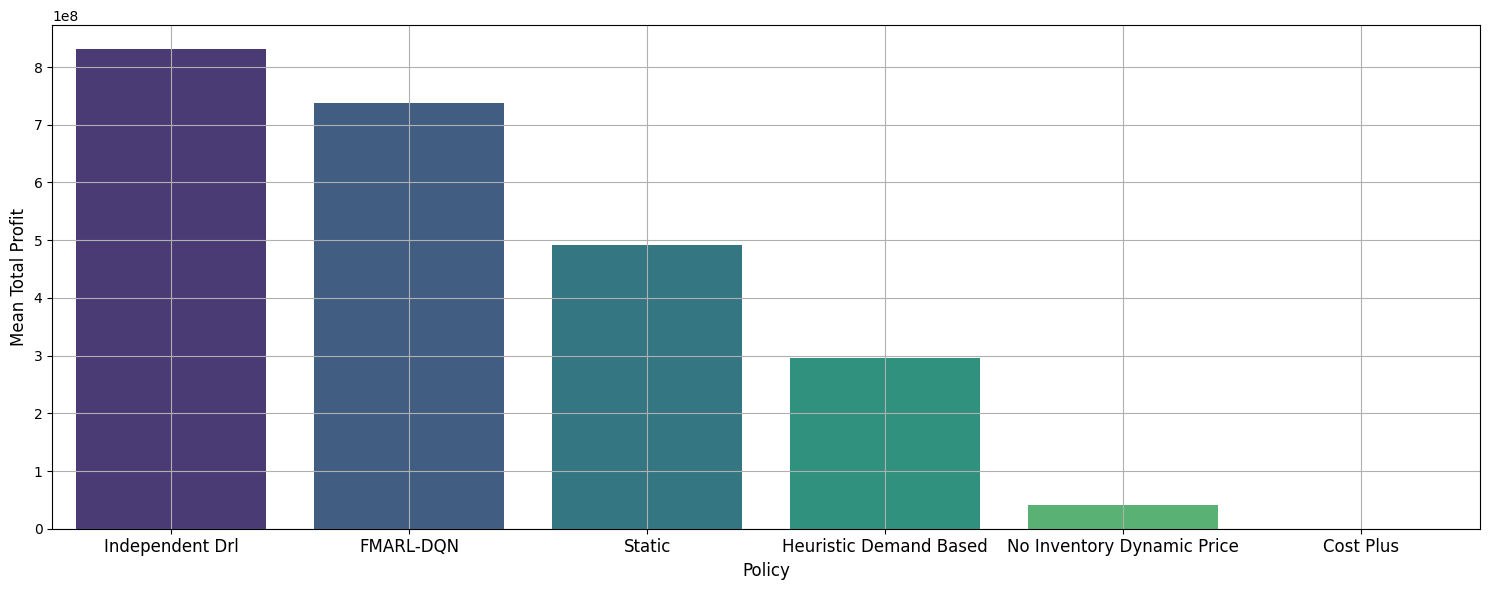

In [ ]:
def extract_mean(value_str):
    match = re.match(r'([\d\.]+e[\+\-]?[\d]+)', value_str)
    if match:
        return float(match.group(1))
    return np.nan

results_df['Mean Profit Value'] = results_df['Mean Total Profit'].apply(extract_mean)
results_df_sorted = results_df.sort_values(by='Mean Profit Value', ascending=False)
results_df_sorted['Policy'] = results_df_sorted['Policy'].replace({'Fmarldqn': 'FMARL-DQN'})

plt.figure(figsize=(15, 6))
sns.barplot(x='Policy', y='Mean Profit Value', data=results_df_sorted, palette='viridis')
plt.xlabel('Policy', fontsize=12)
plt.ylabel('Mean Total Profit', fontsize=12)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.xticks(fontsize=12)
plt.grid()
plt.tight_layout()
plt.show()

## **Statistical Significance Tests**
- Paired t-tests: If the conditions across runs are matched for each policy (e.g., same sequence of random demand shocks across policies for a given run). This is applicable here since we are using the same random_seed for all policies within a run_idx.

- ANOVA (Analysis of Variance): If comparing more than two groups (policies) to see if there is a significant difference between their means. This would be followed by post-hoc tests (e.g., Tukey's HSD) to determine which specific pairs of policies are different.

- Bootstrap Confidence Intervals:Non-parametric involves resampling the collected metrics to estimate the confidence intervals for the mean difference between policies.

In [ ]:
# Total profits for FMARL-DQN and Static policy from all runs
fmarldqn_profits = all_results['fmarldqn']['total_profit']
static_profits = all_results['static']['total_profit']
independent_drl_profits = all_results['independent_drl']['total_profit']

# Paired t-test: FMARL-DQN vs. Static
t_statistic_profit_fmar_static, p_value_profit_fmar_static = stats.ttest_rel(fmarldqn_profits, static_profits)

print(f"\n--- Paired t-test for Total Profit (FMARL-DQN vs. Static) ---")
print(f"T-statistic: {t_statistic_profit_fmar_static:.4f}")
print(f"P-value: {p_value_profit_fmar_static:.4f}")

if p_value_profit_fmar_static < 0.05:
    print("Conclusion: There is a statistically significant difference in total profit between FMARL-DQN and Static policies.")
else:
    print("Conclusion: There is no statistically significant difference in total profit between FMARL-DQN and Static policies.")

# Paired t-test: FMARL-DQN vs. Independent DRL
t_statistic_profit_fmar_ind, p_value_profit_fmar_ind = stats.ttest_rel(fmarldqn_profits, independent_drl_profits)

print(f"\n--- Paired t-test for Total Profit (FMARL-DQN vs. Independent DRL) ---")
print(f"T-statistic: {t_statistic_profit_fmar_ind:.4f}")
print(f"P-value: {p_value_profit_fmar_ind:.4f}")

if p_value_profit_fmar_ind < 0.05:
    print("Conclusion: There is a statistically significant difference in total profit between FMARL-DQN and Independent DRL policies.")
else:
    print("Conclusion: There is no statistically significant difference in total profit between FMARL-DQN and Independent DRL policies.")

# Service Level (FMARL-DQN vs. Static)
fmarldqn_service_level = all_results['fmarldqn']['service_level']
static_service_level = all_results['static']['service_level']

t_statistic_sl, p_value_sl = stats.ttest_rel(fmarldqn_service_level, static_service_level)
print(f"\n--- Paired t-test for Service Level (FMARL-DQN vs. Static) ---")
print(f"T-statistic: {t_statistic_sl:.4f}")
print(f"P-value: {p_value_sl:.4f}")

if p_value_sl < 0.05:
    print("Conclusion: There is a statistically significant difference in service level between FMARL-DQN and Static policies.")
else:
    print("Conclusion: There is no statistically significant difference in service level between FMARL-DQN and Static policies.")



--- Paired t-test for Total Profit (FMARL-DQN vs. Static) ---
T-statistic: 541.7087
P-value: 0.0000
Conclusion: There is a statistically significant difference in total profit between FMARL-DQN and Static policies.

--- Paired t-test for Total Profit (FMARL-DQN vs. Independent DRL) ---
T-statistic: -89.6373
P-value: 0.0000
Conclusion: There is a statistically significant difference in total profit between FMARL-DQN and Independent DRL policies.

--- Paired t-test for Service Level (FMARL-DQN vs. Static) ---
T-statistic: -3488.6962
P-value: 0.0000
Conclusion: There is a statistically significant difference in service level between FMARL-DQN and Static policies.


## **Paired t-test: FMARL-DQN vs. Independent DRL**

--- Paired t-test: FMARL-DQN vs. Independent DRL ---
Mean FMARL-DQN Profit: 7.38e+08
Mean Independent DRL Profit: 8.31e+08
T-statistic: -89.6373
P-value: 1.3487e-96
Conclusion: There is a statistically significant difference in total profit between FMARL-DQN and Independent DRL.


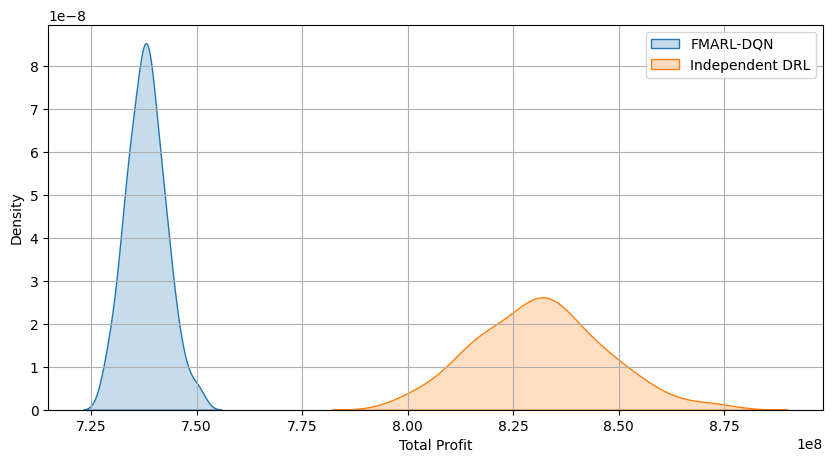

In [ ]:
t_stat_ind, p_val_ind = stats.ttest_rel(fmarldqn_profits, independent_drl_profits)

print(f"--- Paired t-test: FMARL-DQN vs. Independent DRL ---")
print(f"Mean FMARL-DQN Profit: {np.mean(fmarldqn_profits):.2e}")
print(f"Mean Independent DRL Profit: {np.mean(independent_drl_profits):.2e}")
print(f"T-statistic: {t_stat_ind:.4f}")
print(f"P-value: {p_val_ind:.4e}")

if p_val_ind < 0.05:
    print("Conclusion: There is a statistically significant difference in total profit between FMARL-DQN and Independent DRL.")
else:
    print("Conclusion: There is no statistically significant difference in total profit between FMARL-DQN and Independent DRL.")

# Visualization of the profit distributions
plt.figure(figsize=(10, 5))
sns.kdeplot(fmarldqn_profits, label='FMARL-DQN', fill=True)
sns.kdeplot(independent_drl_profits, label='Independent DRL', fill=True)
# plt.title('Profit Distributions: FMARL-DQN vs Independent DRL')
plt.xlabel('Total Profit')
plt.ylabel('Density')
plt.legend()
plt.grid()
plt.show()

## **Effect Size: Cohen's d for two independent samples**

In [ ]:
def calculate_cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (np.mean(group1) - np.mean(group2)) / pooled_std

d_fmarl_indep = calculate_cohens_d(fmarldqn_profits, independent_drl_profits)
d_fmarl_static = calculate_cohens_d(fmarldqn_profits, static_profits)

print(f"--- Effect Size (Cohen's d) ---")
print(f"FMARL-DQN vs Independent DRL: {d_fmarl_indep:.4f}")
print(f"FMARL-DQN vs Static Baseline: {d_fmarl_static:.4f}")

print("\nInterpretation:")
print("0.2: Small | 0.5: Medium | 0.8: Large")

--- Effect Size (Cohen's d) ---
FMARL-DQN vs Independent DRL: -8.4441
FMARL-DQN vs Static Baseline: 34.5811

Interpretation:
0.2: Small | 0.5: Medium | 0.8: Large


### **ANOVA for Total Profit**


In [ ]:
policy_profits_for_anova = []
policy_names_for_anova = []

if 'policy_types_updated' in globals():
    policies_to_iterate = policy_types_updated
else:
    # Fallback if policy_types_updated is not defined (e.g., cell was run out of order)
    policies_to_iterate = [
        "static",
        "cost_plus",
        "heuristic_demand_based",
        "no_inventory_dynamic_price",
        "fmarldqn",
        "independent_drl"]

for policy_type in policies_to_iterate:
    profits = all_results[policy_type]['total_profit']
    policy_profits_for_anova.append(profits)
    policy_names_for_anova.append(policy_type.replace('_', ' ').title())

# One-way ANOVA
f_statistic, p_value_anova = stats.f_oneway(*policy_profits_for_anova)

print(f"\n--- One-Way ANOVA for Total Profit Across All Policies ---")
print(f"F-statistic: {f_statistic:.4f}")
print(f"P-value: {p_value_anova:.4f}")

if p_value_anova < 0.05:
    print("Conclusion: There is a statistically significant difference in mean total profit among the policies.")
    all_profits_flat = [item for sublist in policy_profits_for_anova for item in sublist]
    group_labels = []
    for i, profits_list in enumerate(policy_profits_for_anova):
        group_labels.extend([policy_names_for_anova[i]] * len(profits_list))

    tukey_results = multi.pairwise_tukeyhsd(all_profits_flat, group_labels, alpha=0.05)
    print("\n--- Tukey's HSD Post-Hoc Test Results ---")
    print(tukey_results)
else:
    print("Conclusion: No statistically significant difference in mean total profit among the policies.")


--- One-Way ANOVA for Total Profit Across All Policies ---
F-statistic: 945751.0767
P-value: 0.0000
Conclusion: There is a statistically significant difference in mean total profit among the policies.

--- Tukey's HSD Post-Hoc Test Results ---
                               Multiple Comparison of Means - Tukey HSD, FWER=0.05                                
          group1                     group2               meandiff    p-adj      lower           upper      reject
------------------------------------------------------------------------------------------------------------------
                 Cost Plus                   Fmarldqn  2227112487.937   0.0 2223562153.2481 2230662822.6259   True
                 Cost Plus     Heuristic Demand Based 1783587854.9962   0.0 1780037520.3073 1787138189.6851   True
                 Cost Plus            Independent Drl 2320482712.8994   0.0 2316932378.2105 2324033047.5883   True
                 Cost Plus No Inventory Dynamic Price 1530098481.

### **Bootstrap Confidence Intervals for Mean Profit Difference (FMARL-DQN vs. Static)**


In [ ]:
n_iterations = 1000
bootstrap_diffs_fmar_static = []
bootstrap_diffs_fmar_ind = []

for i in range(n_iterations):
    fmarldqn_sample = np.random.choice(fmarldqn_profits, size=len(fmarldqn_profits), replace=True)
    static_sample = np.random.choice(static_profits, size=len(static_profits), replace=True)
    independent_drl_sample = np.random.choice(independent_drl_profits, size=len(independent_drl_profits), replace=True)

    bootstrap_diffs_fmar_static.append(np.mean(fmarldqn_sample) - np.mean(static_sample))
    bootstrap_diffs_fmar_ind.append(np.mean(fmarldqn_sample) - np.mean(independent_drl_sample))

lower_bound_fmar_static = np.percentile(bootstrap_diffs_fmar_static, 2.5)
upper_bound_fmar_static = np.percentile(bootstrap_diffs_fmar_static, 97.5)

print(f"\n--- Bootstrap 95% Confidence Interval for Mean Profit Difference (FMARL-DQN - Static) ---")
print(f"Mean Difference (FMARL-DQN - Static): {np.mean(fmarldqn_profits) - np.mean(static_profits):.2e}")
print(f"95% Confidence Interval: [{lower_bound_fmar_static:.2e}, {upper_bound_fmar_static:.2e}]")

if lower_bound_fmar_static > 0:
    print("Conclusion: The mean profit of FMARL-DQN is significantly higher than Static (based on bootstrap CI).")
elif upper_bound_fmar_static < 0:
    print("Conclusion: The mean profit of FMARL-DQN is significantly lower than Static (based on bootstrap CI).")
else:
    print("Conclusion: No statistically significant difference in mean profit between FMARL-DQN and Static (based on bootstrap CI).")

# Calculate the 95% confidence interval for FMARL-DQN vs Independent DRL
lower_bound_fmar_ind = np.percentile(bootstrap_diffs_fmar_ind, 2.5)
upper_bound_fmar_ind = np.percentile(bootstrap_diffs_fmar_ind, 97.5)

print(f"\n--- Bootstrap 95% Confidence Interval for Mean Profit Difference (FMARL-DQN - Independent DRL) ---")
print(f"Mean Difference (FMARL-DQN - Independent DRL): {np.mean(fmarldqn_profits) - np.mean(independent_drl_profits):.2e}")
print(f"95% Confidence Interval: [{lower_bound_fmar_ind:.2e}, {upper_bound_fmar_ind:.2e}]")

if lower_bound_fmar_ind > 0:
    print("Conclusion: The mean profit of FMARL-DQN is significantly higher than Independent DRL (based on bootstrap CI).")
elif upper_bound_fmar_ind < 0:
    print("Conclusion: The mean profit of FMARL-DQN is significantly lower than Independent DRL (based on bootstrap CI).")
else:
    print("Conclusion: No statistically significant difference in mean profit between FMARL-DQN and Independent DRL (based on bootstrap CI).")



--- Bootstrap 95% Confidence Interval for Mean Profit Difference (FMARL-DQN - Static) ---
Mean Difference (FMARL-DQN - Static): 2.47e+08
95% Confidence Interval: [2.45e+08, 2.49e+08]
Conclusion: The mean profit of FMARL-DQN is significantly higher than Static (based on bootstrap CI).

--- Bootstrap 95% Confidence Interval for Mean Profit Difference (FMARL-DQN - Independent DRL) ---
Mean Difference (FMARL-DQN - Independent DRL): -9.34e+07
95% Confidence Interval: [-9.65e+07, -9.03e+07]
Conclusion: The mean profit of FMARL-DQN is significantly lower than Independent DRL (based on bootstrap CI).


## **Comparison of Mean Total Profit Across Policies (100 Runs)**

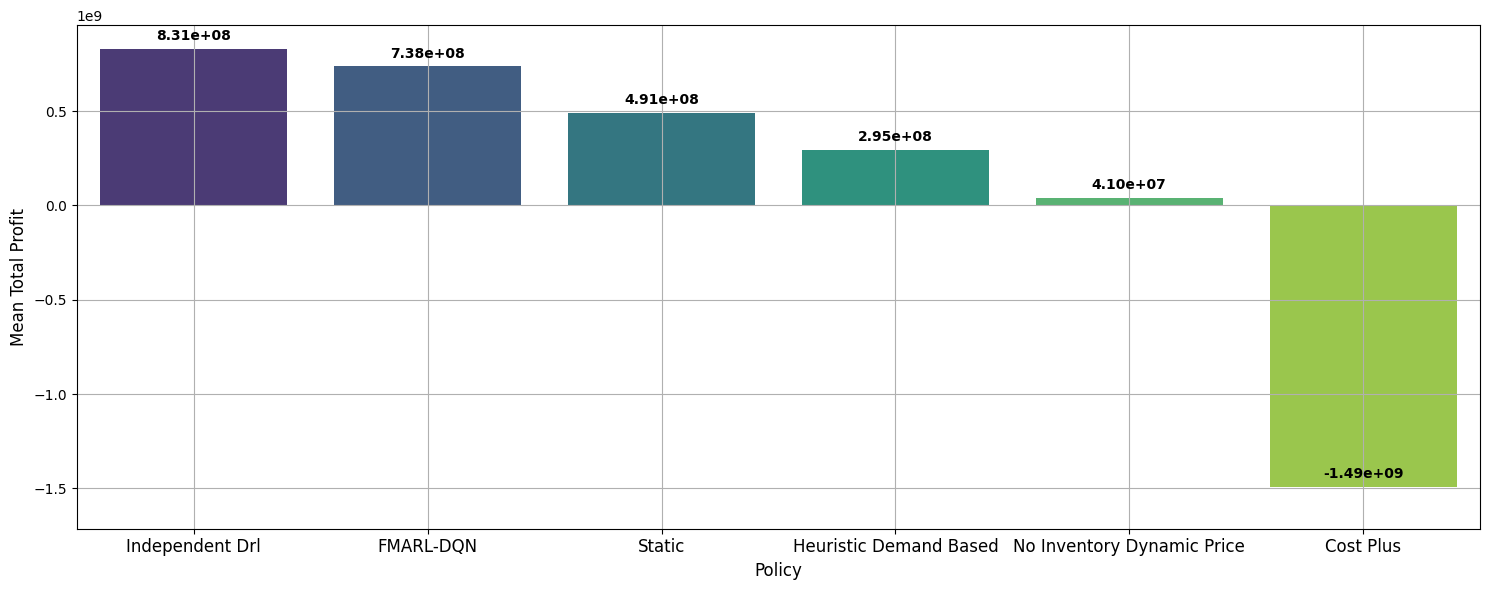

In [ ]:
def extract_mean(value_str):
    match = re.search(r'([-+]?\d*\.?\d+e[+-]?\d+)', str(value_str))
    if match:
        return float(match.group(1))
    return np.nan

results_df['Mean Profit Value'] = results_df['Mean Total Profit'].apply(extract_mean)
results_df_sorted = results_df.sort_values(by='Mean Profit Value', ascending=False)
results_df_sorted['Policy'] = results_df_sorted['Policy'].replace({'Fmarldqn': 'FMARL-DQN'})

plt.figure(figsize=(15, 6))
ax = sns.barplot(x='Policy', y='Mean Profit Value', data=results_df_sorted, hue='Policy', palette='viridis', legend=False)

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2e'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points',
                   fontsize=10, fontweight='bold')

plt.xlabel('Policy', fontsize=12)
plt.ylabel('Mean Total Profit', fontsize=12)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.xticks(fontsize=12)
plt.grid()
plt.ylim(results_df_sorted['Mean Profit Value'].min() * 1.15, results_df_sorted['Mean Profit Value'].max() * 1.15)
plt.tight_layout()
plt.show()

In [ ]:
variance_data = []

for policy_type in policies_to_iterate:
    profits = all_results[policy_type]['total_profit']
    variance_data.append({
        'Policy': policy_type.replace('_', ' ').title().replace('Fmarldqn', 'FMARL-DQN'),
        'Std Dev (Profit)': np.std(profits),
        'Variance (Profit)': np.var(profits)})

variance_df = pd.DataFrame(variance_data)
variance_df['Std Dev (Profit)'] = variance_df['Std Dev (Profit)'].apply(lambda x: f'{x:.4e}')
variance_df['Variance (Profit)'] = variance_df['Variance (Profit)'].apply(lambda x: f'{x:.4e}')

display(variance_df)

,Policy,Std Dev (Profit),Variance (Profit)
0,Static,8.9507e+06,8.0116e+13
1,Cost Plus,8.4847e+06,7.1991e+13
2,Heuristic Demand Based,7.9869e+06,6.3791e+13
3,No Inventory Dynamic Price,2.8032e+04,7.8577e+08
4,FMARL-DQN,4.5398e+06,2.0610e+13
5,Independent Drl,1.4882e+07,2.2148e+14


In [ ]:
summary_data = []

for policy_type in policies_to_iterate:
    profits = all_results[policy_type]['total_profit']
    service_levels = all_results[policy_type]['service_level']

    summary_data.append({
        'Policy': policy_type.replace('_', ' ').title().replace('Fmarldqn', 'FMARL-DQN'),
        'Mean Profit': np.mean(profits),
        'Std Dev (Profit)': np.std(profits),
        'Mean Service Level': np.mean(service_levels)})

summary_df = pd.DataFrame(summary_data)
styled_summary = summary_df.copy()
styled_summary['Mean Profit'] = styled_summary['Mean Profit'].apply(lambda x: f'{x:.4e}')
styled_summary['Std Dev (Profit)'] = styled_summary['Std Dev (Profit)'].apply(lambda x: f'{x:.4e}')
styled_summary['Mean Service Level'] = styled_summary['Mean Service Level'].apply(lambda x: f'{x:.4f}')

display(styled_summary)

,Policy,Mean Profit,Std Dev (Profit),Mean Service Level
0,Static,4.9140e+08,8.9507e+06,0.8085
1,Cost Plus,-1.4891e+09,8.4847e+06,0.0486
2,Heuristic Demand Based,2.9452e+08,7.9869e+06,0.7597
3,No Inventory Dynamic Price,4.1032e+07,2.8032e+04,0.0058
4,FMARL-DQN,7.3805e+08,4.5398e+06,0.5275
5,Independent Drl,8.3142e+08,1.4882e+07,0.6631


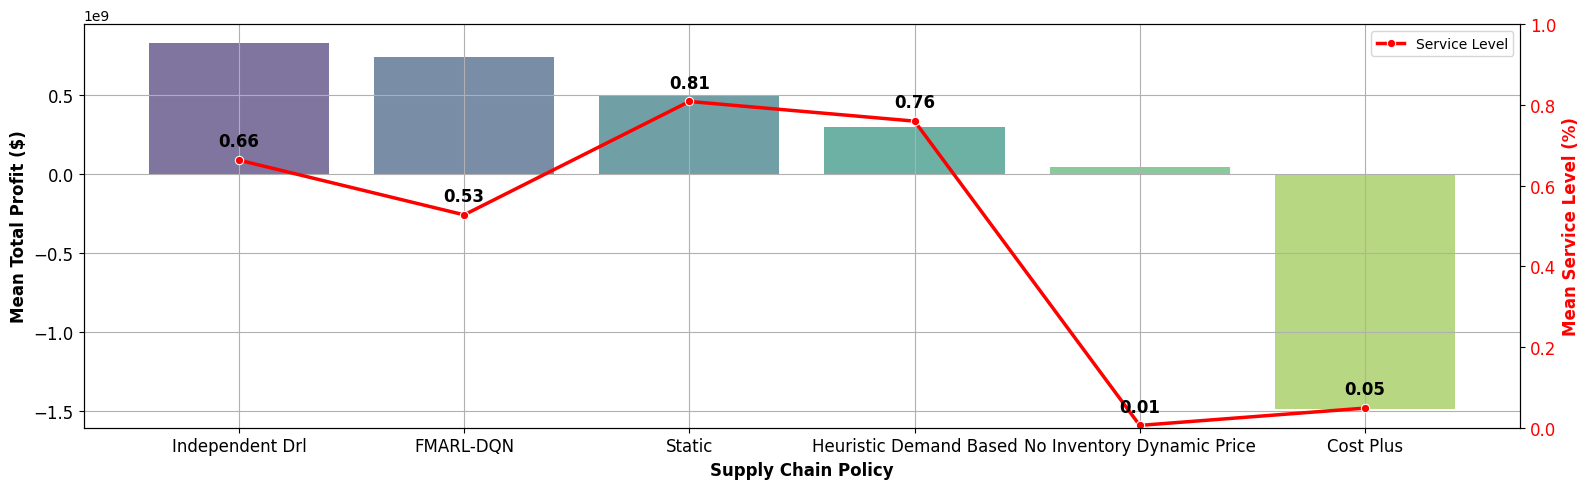

In [ ]:
plot_df = summary_df.copy()
plot_df = plot_df.sort_values('Mean Profit', ascending=False)

fig, ax1 = plt.subplots(figsize=(16, 5))

sns.barplot(x='Policy', y='Mean Profit', data=plot_df, ax=ax1, palette='viridis', alpha=0.7, hue='Policy', legend=False)
ax1.set_ylabel('Mean Total Profit ($)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Supply Chain Policy', fontsize=12, fontweight='bold')
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.grid()

ax2 = ax1.twinx()
sns.lineplot(x='Policy', y='Mean Service Level', data=plot_df, ax=ax2, color='red', marker='o', linewidth=2.5, label='Service Level')
ax2.set_ylabel('Mean Service Level (%)', fontsize=12, color='red', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='red', labelsize=12)
ax2.set_ylim(0, 1.0)

for i, txt in enumerate(plot_df['Mean Service Level']):
    ax2.annotate(f'{txt:.2f}', (i, plot_df['Mean Service Level'].iloc[i]),
                 textcoords="offset points", xytext=(0,10), ha='center', color='k', fontweight='bold', fontsize=12)

fig.tight_layout()
plt.show()

### **Consolidated Statistical & Performance Report**


In [ ]:
report_df = pd.DataFrame(aggregated_results)
ci_data = {
    'Static': f'[{lower_bound_fmar_static:.2e}, {upper_bound_fmar_static:.2e}]',
    'Independent Drl': f'[{lower_bound_fmar_ind:.2e}, {upper_bound_fmar_ind:.2e}]'}
report_df['Bootstrap CI (vs FMARL)'] = report_df['Policy'].map(ci_data).fillna('-')

anova_summary = f'F={f_statistic:.2f}, p={p_value_anova:.4f}'

report_df.columns = [
    'Policy', 'Profit (Mean ± Std)', 'Service Level',
    'Avg Inventory', 'Stockout Rate', 'Bootstrap CI (Diff vs FMARL)']

print(f'One-Way ANOVA Result: {anova_summary}')
display(report_df.style.set_caption('Comprehensive Supply Chain Policy Evaluation Report'))

One-Way ANOVA Result: F=945751.08, p=0.0000


,Policy,Profit (Mean ± Std),Service Level,Avg Inventory,Stockout Rate,Bootstrap CI (Diff vs FMARL)
0,Static,4.91e+08 ± 8.95e+06,8.08e-01 ± 2.76e-03,6.05e+03 ± 3.05e+01,1.92e-01 ± 2.76e-03,"[2.45e+08, 2.49e+08]"
1,Cost Plus,-1.49e+09 ± 8.48e+06,4.86e-02 ± 1.63e-04,8.39e+03 ± 2.98e+01,9.51e-01 ± 1.63e-04,-
2,Heuristic Demand Based,2.95e+08 ± 7.99e+06,7.60e-01 ± 2.68e-03,5.61e+03 ± 2.99e+01,2.40e-01 ± 2.68e-03,-
3,No Inventory Dynamic Price,4.10e+07 ± 2.80e+04,5.77e-03 ± 2.77e-05,3.33e+00 ± 6.00e-02,9.94e-01 ± 2.77e-05,-
4,Fmarldqn,7.38e+08 ± 4.54e+06,5.27e-01 ± 2.00e-03,1.93e+03 ± 1.77e+01,4.73e-01 ± 2.00e-03,-
5,Independent Drl,8.31e+08 ± 1.49e+07,6.63e-01 ± 1.41e-03,5.36e+03 ± 4.81e+01,3.37e-01 ± 1.41e-03,"[-9.65e+07, -9.03e+07]"
